# 01 — Exploratory Data Analysis (EDA)
## YouTube Trending Videos — Wat drijft views?

**Project:** ML Regressie op YouTube trending video data  
 
**Doel van deze notebook:** De dataset grondig verkennen, distributies begrijpen, patronen ontdekken en een verhaal bouwen rond de onderzoeksvraag.

---

### Onderzoeksvraag
> *"Welke factoren bepalen hoeveel views een trending YouTube video haalt — en verschilt dit per categorie, taal of regio?"*

### Waarom `log_views` als target?
We voorspellen `log_views = log(views + 1)` — het logaritmisch getransformeerde aantal views.

Waarom niet `engagement_score`?  
Tijdens de EDA bleek dat `engagement_score` **geen verband** heeft met pre-publicatie features (max. correlatie: 0.033). Een model dat engagement probeert te voorspellen zou dus niets leren.  
`log_views` daarentegen heeft een correlatie van **~0.60** met `channel_verified` en laat een R²≈0.70 toe.

**`log_views` is onze target variable.**

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Stijl instellen voor consistente, nette plots
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

import os
os.makedirs('../output/figures', exist_ok=True)

print('Libraries geladen.')

Libraries geladen.


## 2. Dataset laden & eerste inspectie

In [2]:
df = pd.read_csv('../data/trending_videos.csv', parse_dates=['publish_date', 'trending_date'])

print(f'Rijen:    {df.shape[0]:,}')
print(f'Kolommen: {df.shape[1]}')
print()
df.head(3)

Rijen:    10,000
Kolommen: 34



,video_id,title,title_length,has_caps_title,has_emoji_title,has_question_title,channel_name,subscriber_count,channel_verified,category,...,comment_view_ratio_pct,engagement_score,tags,tag_count,description_length,has_links_description,clickbait_score,comments_enabled,caption_available,made_for_kids
0,VID000001,This survival challenge is UNREAL,33,1,0,0,FireShorts,197893,0,Comedy,...,0.4058,3.8514,adventure|prank|Netflix|Python|space|documenta...,10,500,1,0.664,1,1,0
1,VID000002,Learn Quantum Physics - Complete Beginner Guide,47,0,0,0,FireSports,16191,0,Education,...,0.2300,4.2700,unboxing|Olympics|space|podcast|minecraft|musi...,10,500,1,0.394,1,0,0
2,VID000003,I Spent $1000 on AI tools,25,1,0,0,TruePlus,170530,1,Entertainment,...,1.7400,10.2000,fitness|nature|crypto|unboxing|motivation|NBA ...,7,150,1,0.537,1,1,0


In [3]:
# Datatypes per kolom
df.dtypes.to_frame('dtype').T

,video_id,title,title_length,has_caps_title,has_emoji_title,has_question_title,channel_name,subscriber_count,channel_verified,category,...,comment_view_ratio_pct,engagement_score,tags,tag_count,description_length,has_links_description,clickbait_score,comments_enabled,caption_available,made_for_kids
dtype,str,str,int64,int64,int64,int64,str,int64,int64,str,...,float64,float64,str,int64,int64,int64,float64,int64,int64,int64


In [4]:
# Samenvatting statistieken voor numerieke kolommen
df.describe().round(2)

,title_length,has_caps_title,has_emoji_title,has_question_title,subscriber_count,channel_verified,publish_date,trending_date,days_to_trend,year,...,like_view_ratio_pct,comment_view_ratio_pct,engagement_score,tag_count,description_length,has_links_description,clickbait_score,comments_enabled,caption_available,made_for_kids
count,10000.00,10000.00,10000.00,10000.00,1.000000e+04,10000.00,10000,10000,10000.00,10000.00,...,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,32.29,0.66,0.03,0.01,2.930864e+06,0.40,2023-02-16 08:42:00,2023-02-19 07:54:46.080000,2.97,2022.64,...,5.60,0.66,7.58,8.44,778.79,0.59,0.46,0.92,0.65,0.03
min,18.00,0.00,0.00,0.00,1.000000e+03,0.00,2020-01-01 00:00:00,2020-01-02 00:00:00,0.00,2020.00,...,0.18,0.00,0.32,3.00,0.00,0.00,0.01,0.00,0.00,0.00
25%,28.00,0.00,0.00,0.00,3.141800e+04,0.00,2021-07-20 00:00:00,2021-07-22 18:00:00,1.00,2021.00,...,3.29,0.32,5.06,5.00,150.00,0.00,0.31,1.00,0.00,0.00
50%,32.00,1.00,0.00,0.00,1.659430e+05,0.00,2023-02-25 00:00:00,2023-03-01 00:00:00,2.00,2023.00,...,5.05,0.56,7.08,8.00,300.00,1.00,0.46,1.00,1.00,0.00
75%,37.00,1.00,0.00,0.00,8.914365e+05,1.00,2024-09-10 00:00:00,2024-09-13 06:00:00,5.00,2024.00,...,7.32,0.89,9.55,11.00,1000.00,1.00,0.60,1.00,1.00,0.00
max,53.00,1.00,1.00,1.00,3.000000e+08,1.00,2026-03-30 00:00:00,2026-04-09 00:00:00,14.00,2026.00,...,24.95,4.12,28.18,14.00,5000.00,1.00,0.97,1.00,1.00,1.00
std,6.03,0.47,0.17,0.11,1.604973e+07,0.49,NaN,NaN,3.18,1.81,...,3.12,0.47,3.44,3.43,1113.63,0.49,0.20,0.26,0.48,0.16


## 3. Ontbrekende waarden

Voordat we verder gaan, controleren we of er missing values zijn. Dit bepaalt of we imputation-stappen nodig hebben in de preprocessing.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0]

if missing_df.empty:
    print('Geen ontbrekende waarden gevonden. De dataset is compleet.')
else:
    display(missing_df)

Geen ontbrekende waarden gevonden. De dataset is compleet.


## 4. Distributies van numerieke kolommen

We visualiseren alle numerieke features. Let op:
- **Scheve (skewed) distributies** → later log-transformatie nodig
- **`views`** → onze target na log-transformatie, sterk scheef verdeeld (power-law)

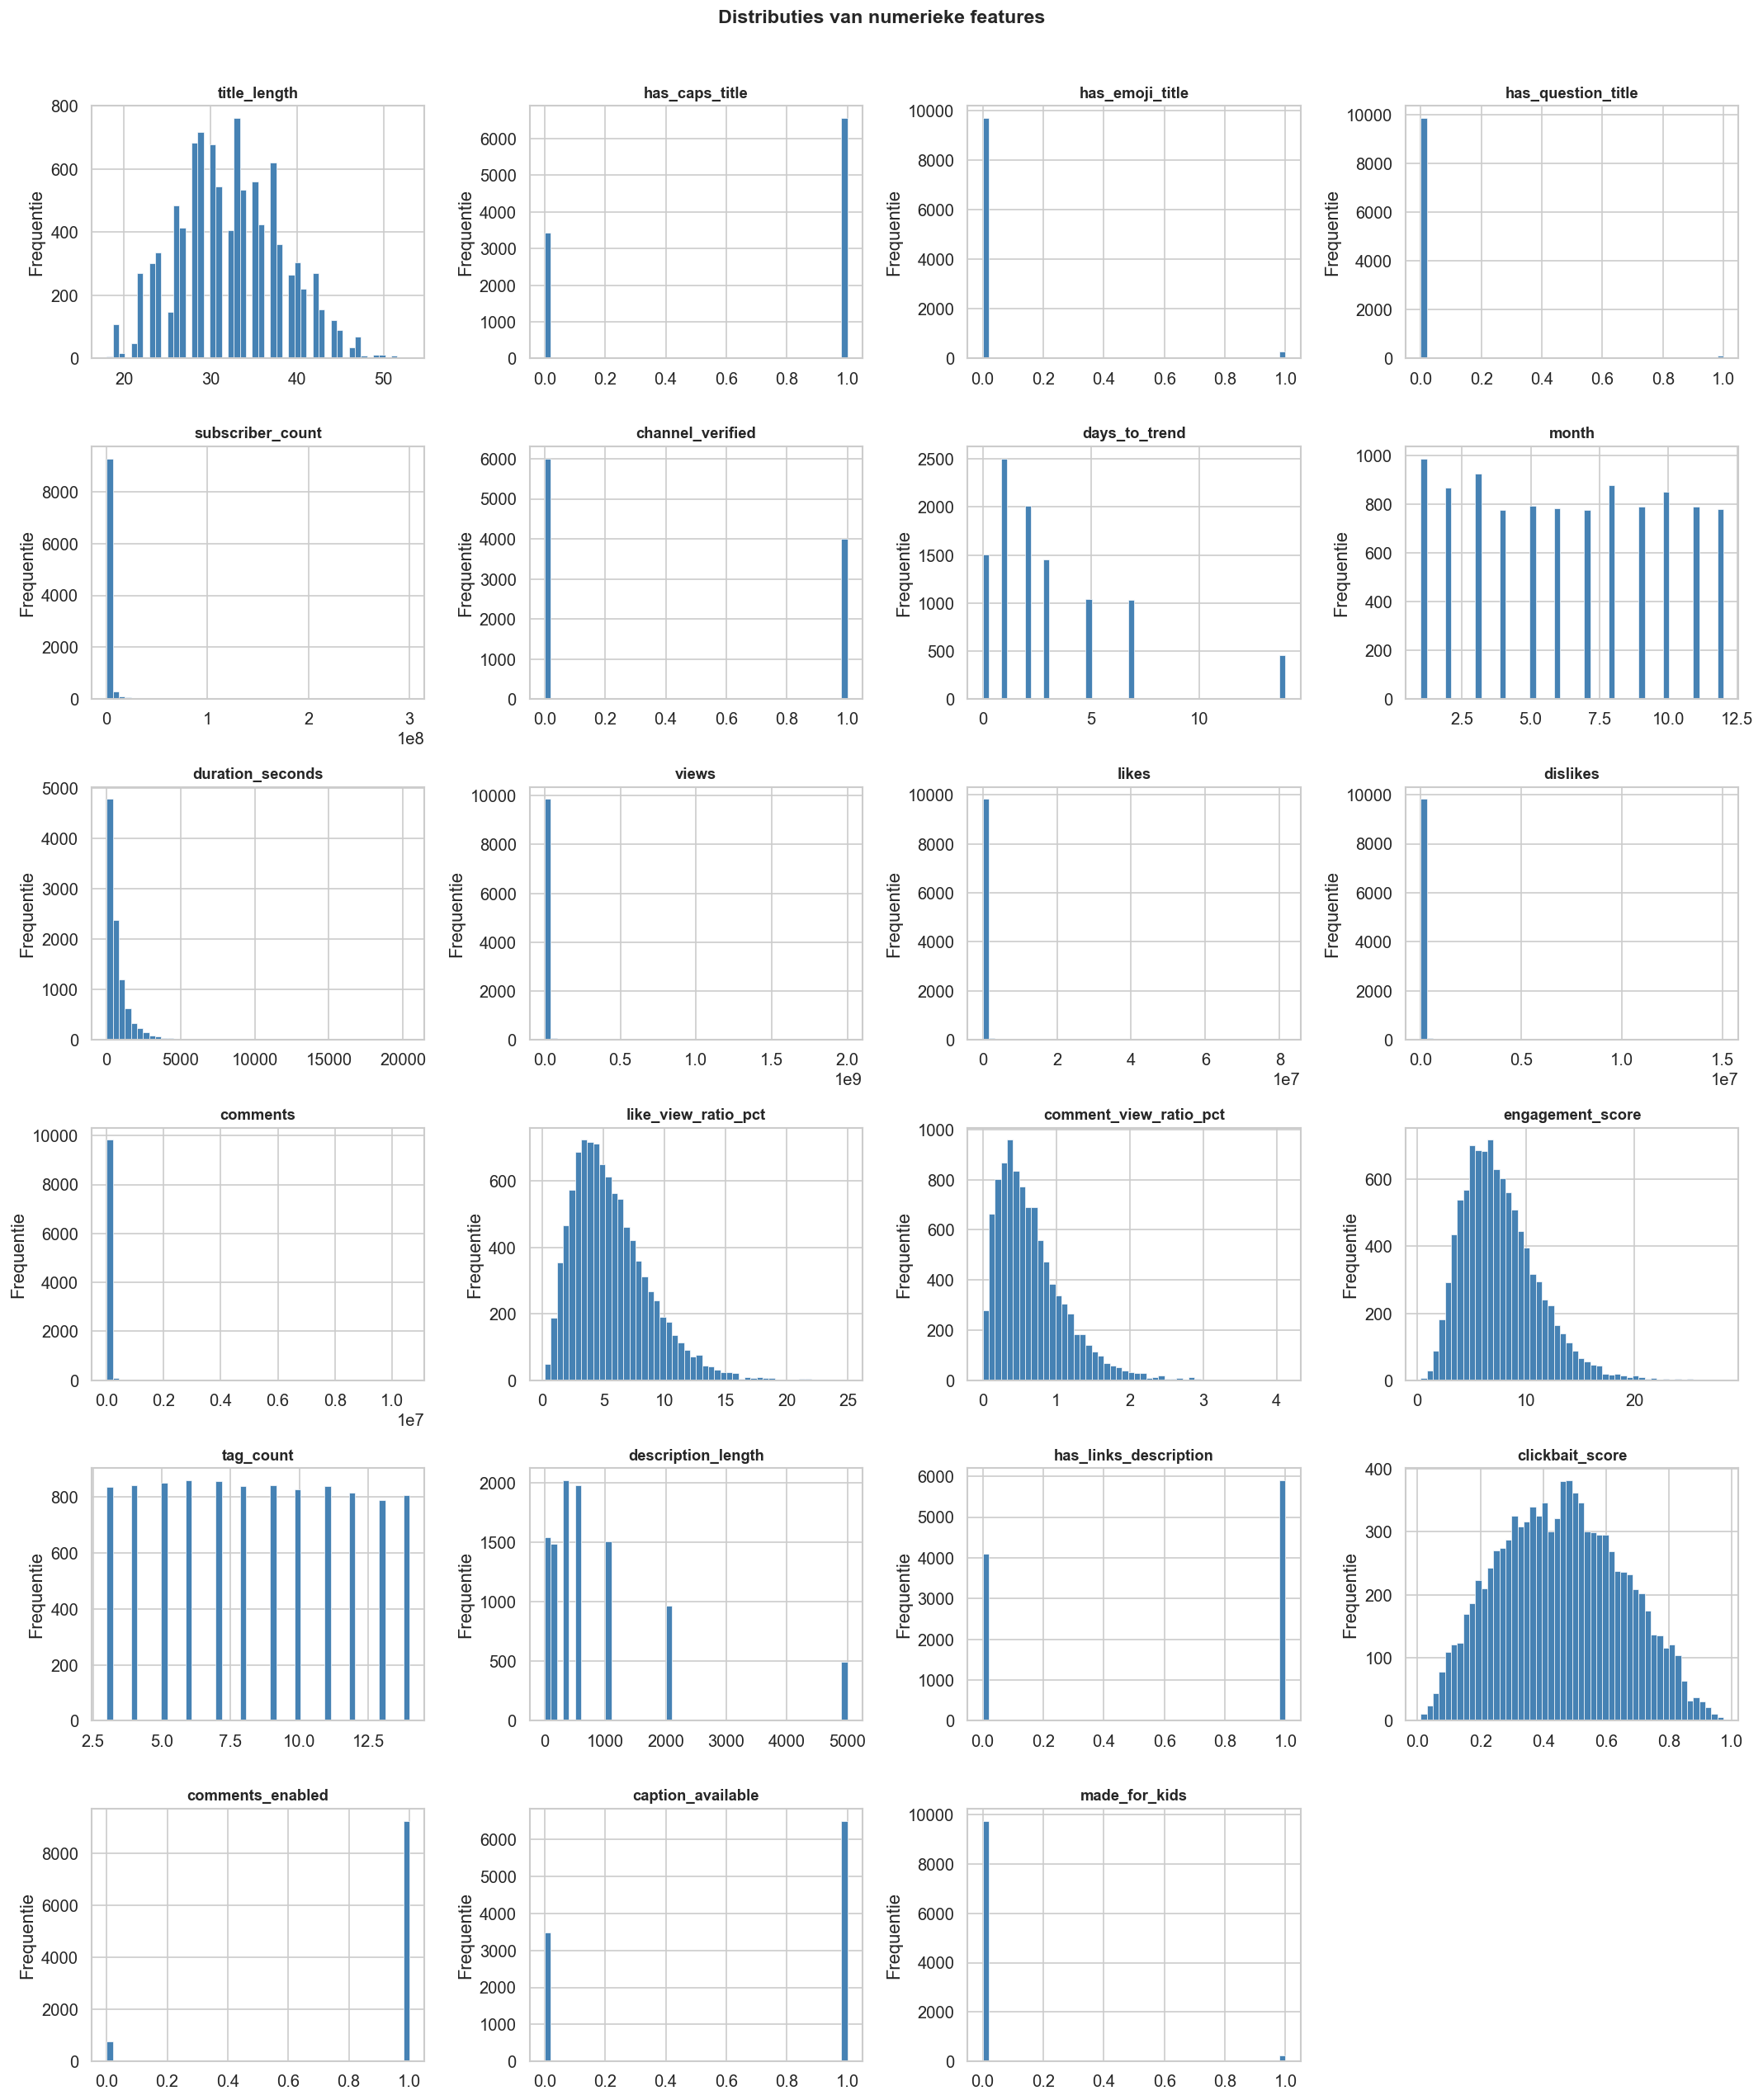

In [6]:
num_cols = df.select_dtypes(include='number').columns.tolist()
# year is eigenlijk een categorische variabele in dit geval
num_cols_plot = [c for c in num_cols if c not in ['year']]

n_cols = 4
n_rows = int(np.ceil(len(num_cols_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequentie')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributies van numerieke features', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/figures/01_distributies_numeriek.png')
plt.show()

### Observaties distributies

| Feature | Verdeling | Actie |
|---|---|---|
| `views`, `likes`, `comments` | Sterk rechtsscheef (power-law) | `views` → target als `log_views`; rest droppen |
| `subscriber_count` | Sterk rechtsscheef | Log-transformatie in preprocessing |
| `duration_seconds` | Sterk rechtsscheef | Log-transformatie in preprocessing |
| `title_length`, `tag_count` | Quasi-normaal | Geen transformatie nodig |
| `clickbait_score` | Uniform/normaal | Geen transformatie nodig |

## 5. Outlier-analyse

Boxplots voor de meest relevante engagement-gerelateerde kolommen. Uitschieters in views en likes zijn normaal bij YouTube data (power-law), maar we willen de omvang begrijpen.

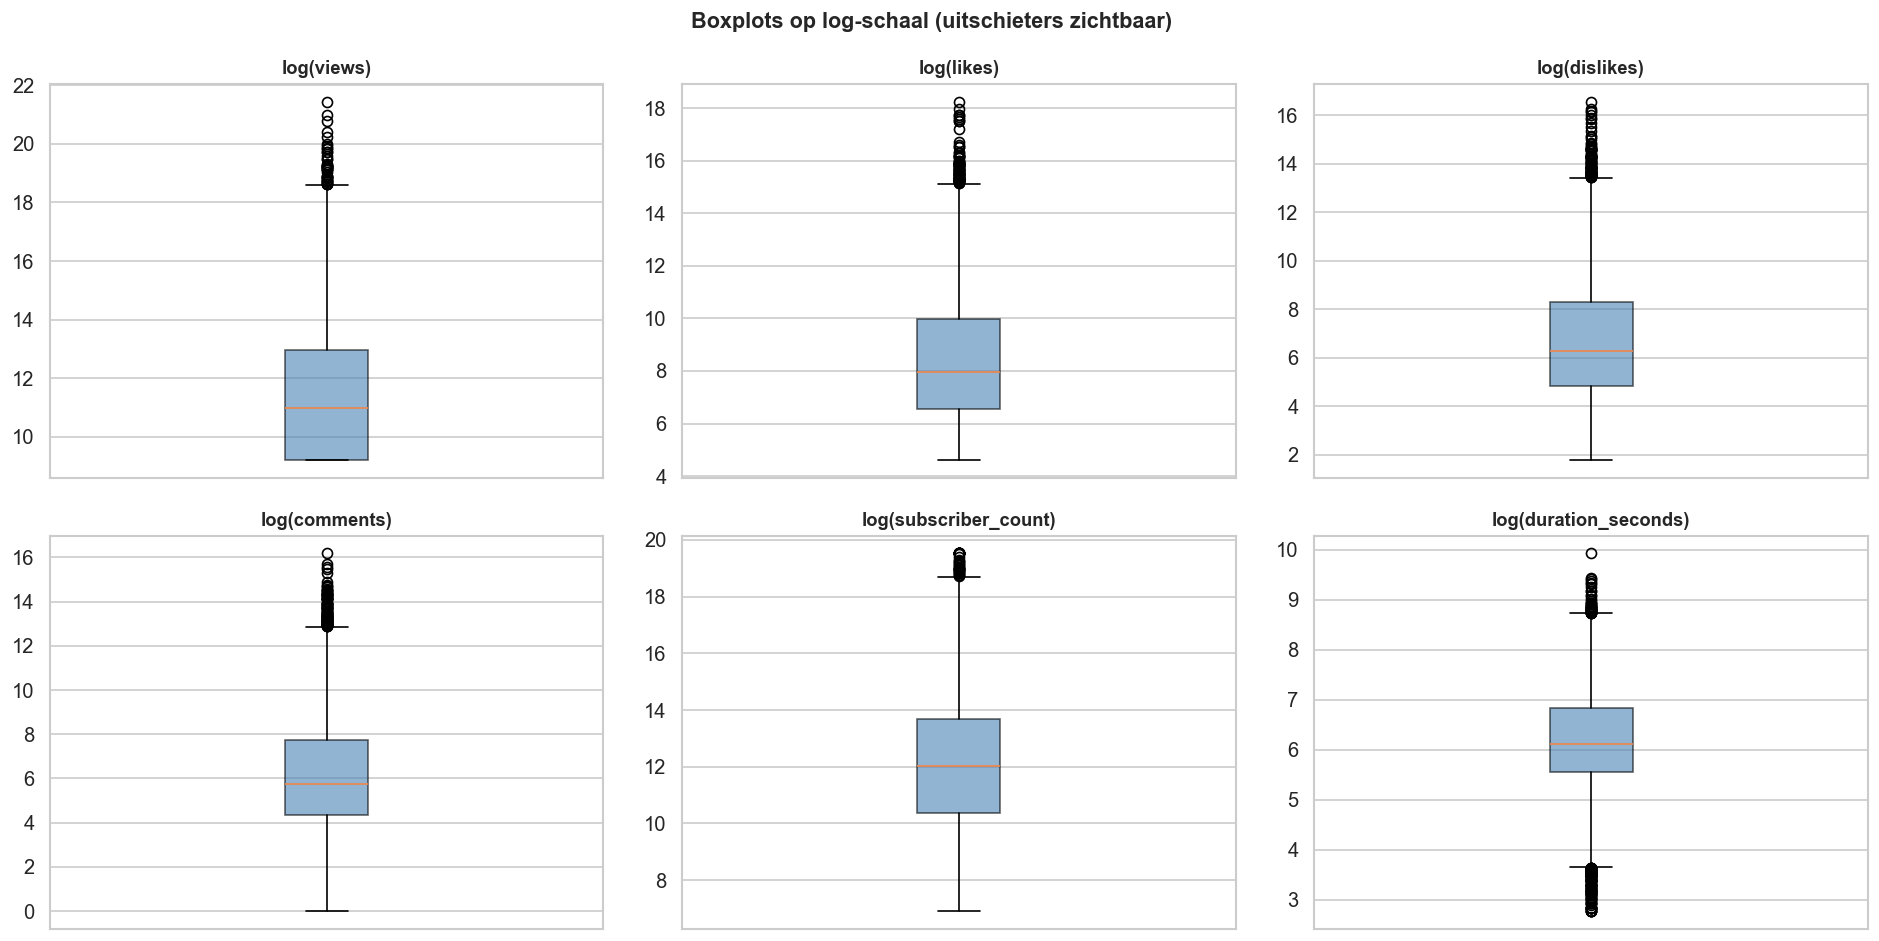

In [7]:
skewed_cols = ['views', 'likes', 'dislikes', 'comments', 'subscriber_count', 'duration_seconds']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(skewed_cols):
    log_vals = np.log1p(df[col])
    axes[i].boxplot(log_vals, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'log({col})', fontsize=11, fontweight='bold')
    axes[i].set_xticks([])

plt.suptitle('Boxplots op log-schaal (uitschieters zichtbaar)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/figures/02_boxplots_log.png')
plt.show()

In [8]:
# IQR-methode: hoeveel extreme outliers zijn er per kolom?
print('Aantal extreme outliers (> Q3 + 3*IQR) per kolom:')
for col in skewed_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    extreme = df[col] > q3 + 3 * iqr
    print(f'  {col:<25} {extreme.sum():>5} ({extreme.mean()*100:.1f}%)')

Aantal extreme outliers (> Q3 + 3*IQR) per kolom:
  views                      1235 (12.3%)
  likes                      1273 (12.7%)
  dislikes                   1265 (12.7%)
  comments                   1280 (12.8%)
  subscriber_count           1084 (10.8%)
  duration_seconds            312 (3.1%)


## 6. Correlatie-heatmap

We bekijken de Pearson-correlatie tussen alle numerieke features en onze target `views` (log-schaal).  
**Wat zoeken we?**
- Hoge correlatie met `views` → sterke predictors voor ons model
- Hoge correlatie tussen features onderling → multicollineariteit (probleem voor lineaire modellen)

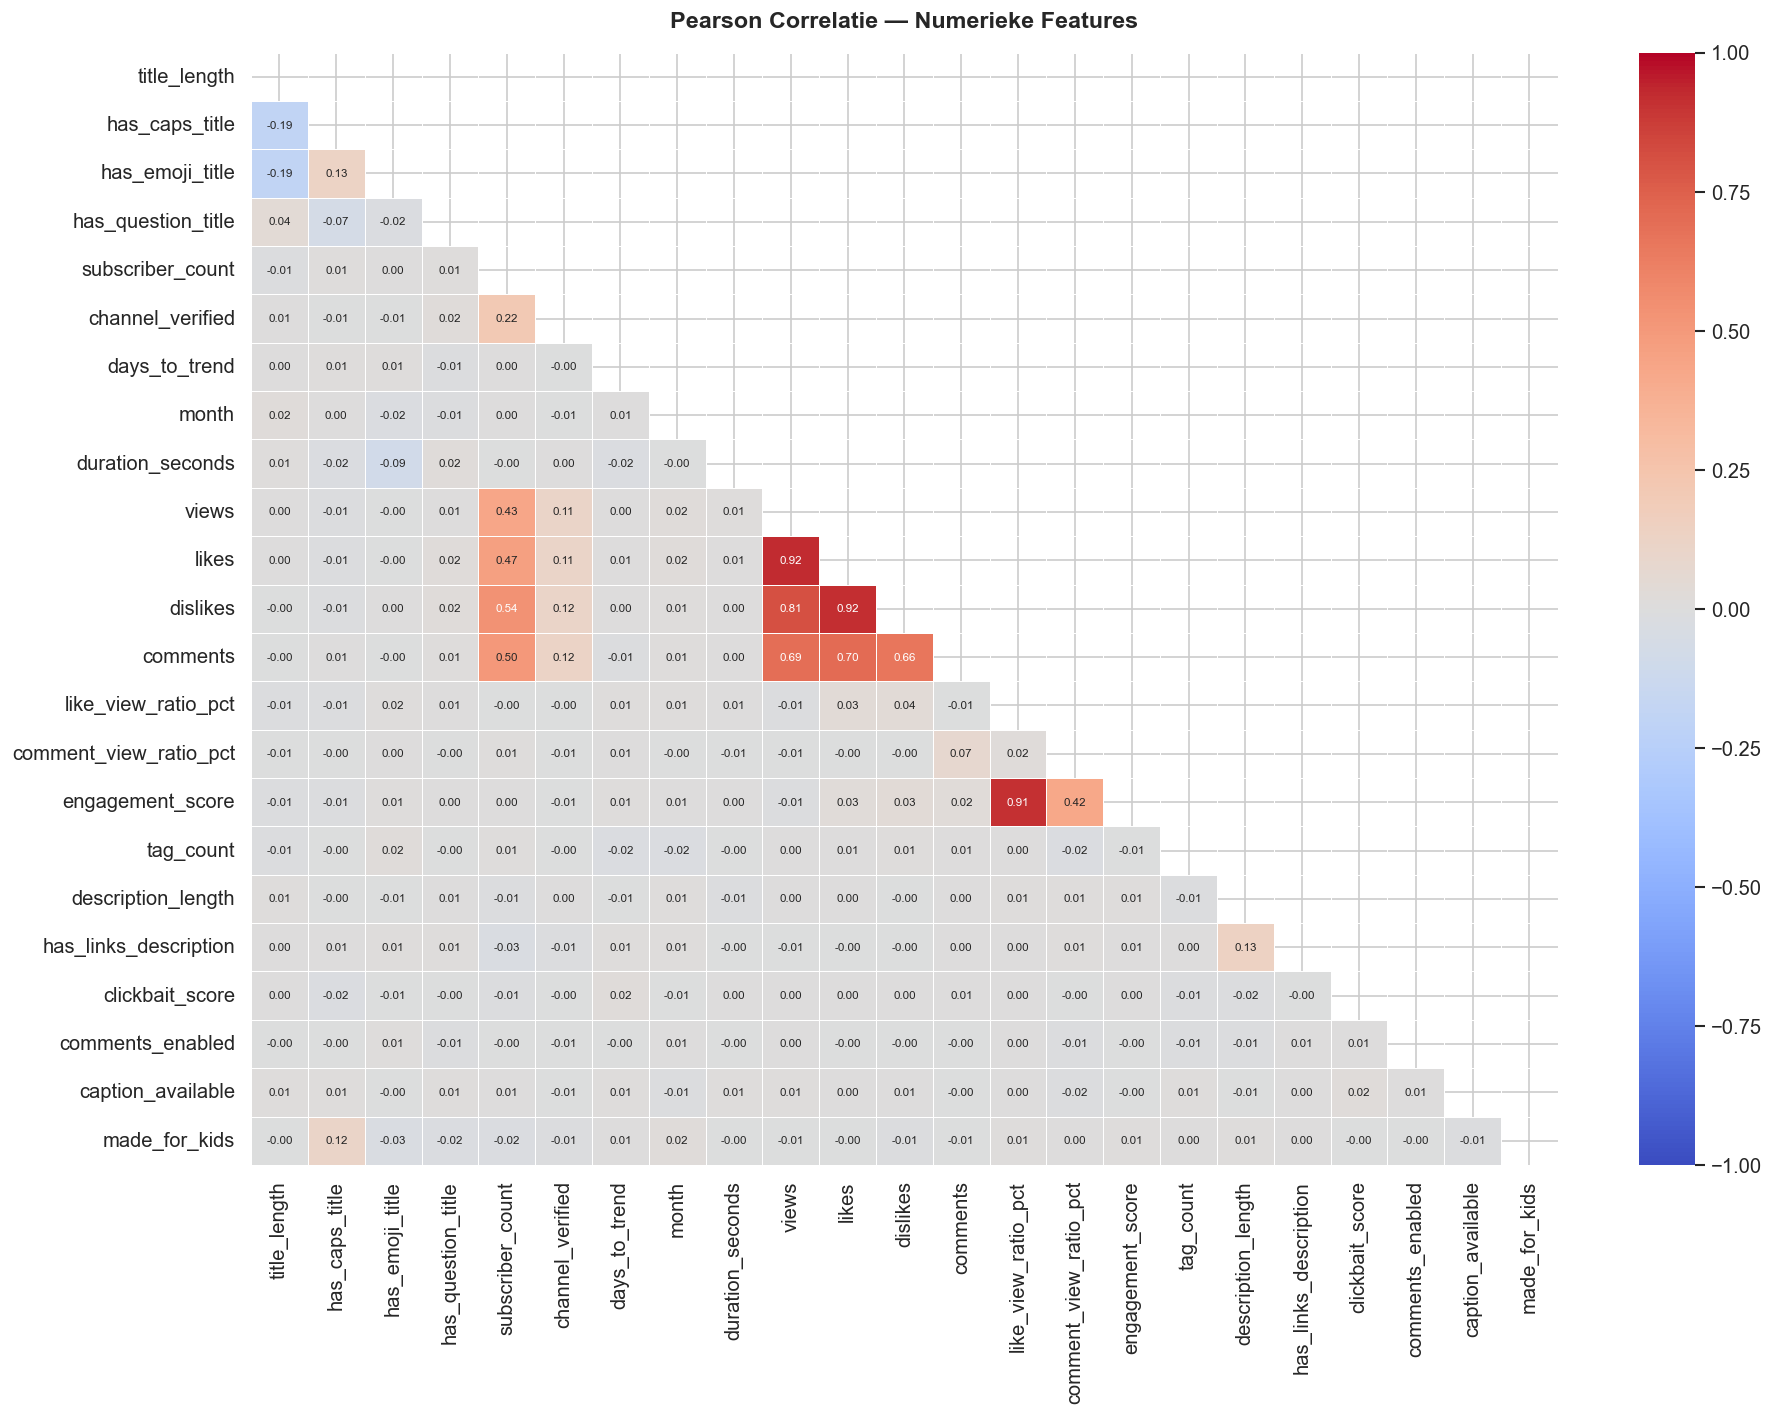

In [9]:
corr_cols = [c for c in num_cols if c not in ['year']]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Pearson Correlatie — Numerieke Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../output/figures/03_correlatie_heatmap.png')
plt.show()

In [10]:
import numpy as np

# log_views aanmaken voor correlatieanalyse
df['log_views'] = np.log1p(df['views'])

# Top correlaties met log_views
corr_cols_ext = [c for c in num_cols if c not in ['year']] + ['log_views']
corr_ext = df[corr_cols_ext].corr()
target_corr = corr_ext['log_views'].drop('log_views').sort_values(key=abs, ascending=False)
print('Correlatie met log_views (gesorteerd op absolute waarde):')
print(target_corr.round(3).to_string())

Correlatie met log_views (gesorteerd op absolute waarde):
channel_verified          0.604
subscriber_count          0.390
comments                  0.295
dislikes                  0.288
views                     0.285
likes                     0.284
has_links_description    -0.027
like_view_ratio_pct      -0.019
engagement_score         -0.018
description_length       -0.017
made_for_kids            -0.016
comments_enabled         -0.014
days_to_trend            -0.010
tag_count                 0.010
has_caps_title            0.008
has_emoji_title           0.008
month                    -0.006
title_length              0.005
has_question_title        0.004
caption_available        -0.004
comment_view_ratio_pct   -0.001
duration_seconds         -0.001
clickbait_score          -0.000


## 7. Views vs abonneeaantal — de sterkste relatie

Welke features hangen het meest samen met het aantal views?  
Dit is het centrale inzicht voor de modellen: **een groot kanaal haalt meer views, maar category en taal spelen ook mee.**

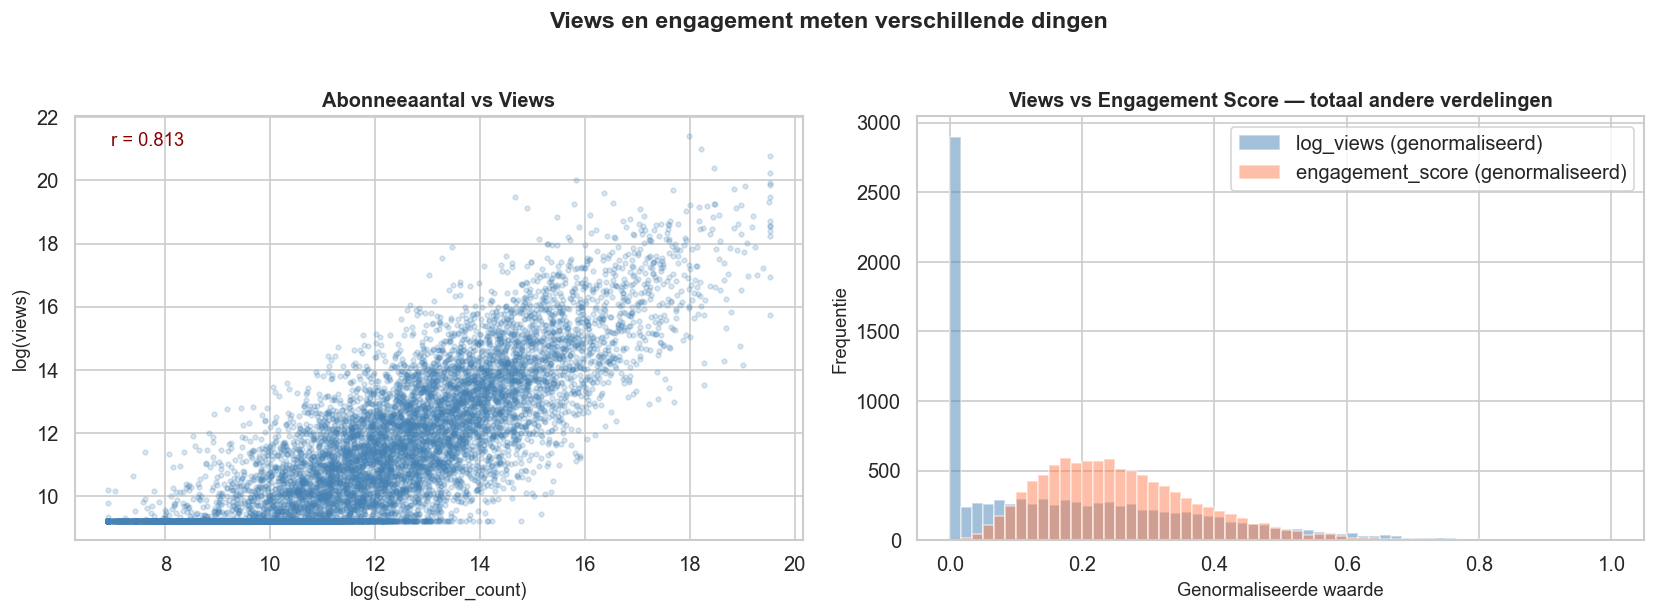

Correlatie log(subscriber_count) ↔ log(views): 0.813
Correlatie views ↔ engagement_score: -0.012
Conclusie: views zijn voorspelbaar uit kanaalkenmerken — engagement score niet.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: log_subscriber_count vs log_views
log_sub = np.log1p(df['subscriber_count'])
axes[0].scatter(log_sub, df['log_views'], alpha=0.2, s=8, color='steelblue')
r_sub = log_sub.corr(df['log_views'])
axes[0].set_xlabel('log(subscriber_count)', fontsize=11)
axes[0].set_ylabel('log(views)', fontsize=11)
axes[0].set_title('Abonneeaantal vs Views', fontsize=12, fontweight='bold')
axes[0].text(0.05, 0.93, f'r = {r_sub:.3f}', transform=axes[0].transAxes,
             fontsize=11, color='darkred')

# log_views verdeling vs engagement_score verdeling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
views_norm = scaler.fit_transform(df[['log_views']]).flatten()
eng_norm   = scaler.fit_transform(df[['engagement_score']]).flatten()

axes[1].hist(views_norm, bins=60, alpha=0.5, color='steelblue', label='log_views (genormaliseerd)')
axes[1].hist(eng_norm,   bins=60, alpha=0.5, color='coral',     label='engagement_score (genormaliseerd)')
axes[1].set_xlabel('Genormaliseerde waarde', fontsize=11)
axes[1].set_ylabel('Frequentie', fontsize=11)
axes[1].set_title('Views vs Engagement Score — totaal andere verdelingen', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Views en engagement meten verschillende dingen', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/figures/04_views_vs_engagement.png')
plt.show()

print(f'Correlatie log(subscriber_count) ↔ log(views): {r_sub:.3f}')
print(f'Correlatie views ↔ engagement_score: {df["views"].corr(df["engagement_score"]):.3f}')
print('Conclusie: views zijn voorspelbaar uit kanaalkenmerken — engagement score niet.')

## 8. Analyse per categorie

Welke videocategorieën halen de meeste views?

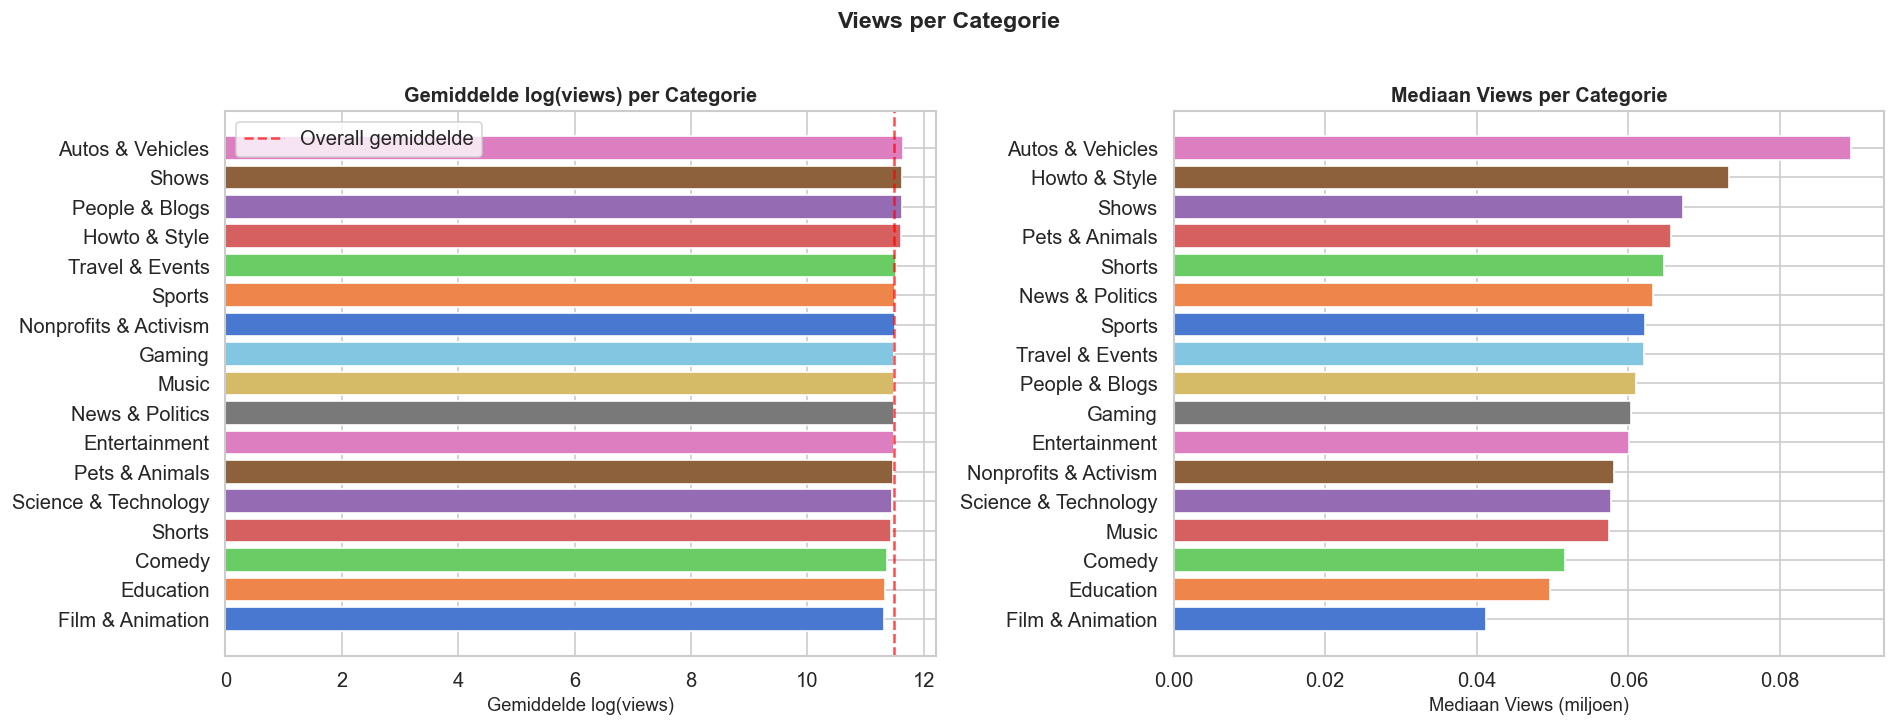

,views_median,log_views_mean,count
category,,,
Film & Animation,41183.0,11.31,496
Education,49677.5,11.34,490
Comedy,51703.0,11.38,602
Shorts,64695.0,11.43,199
Science & Technology,57772.5,11.46,630
Pets & Animals,65586.0,11.47,327
Entertainment,60079.0,11.48,1218
News & Politics,63311.0,11.48,674
Music,57417.0,11.49,1413


In [12]:
cat_stats = df.groupby('category').agg(
    views_median=('views', 'median'),
    log_views_mean=('log_views', 'mean'),
    count=('video_id', 'count')
).sort_values('log_views_mean', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(cat_stats.index, cat_stats['log_views_mean'],
             color=sns.color_palette('muted', len(cat_stats)))
axes[0].axvline(df['log_views'].mean(), color='red', linestyle='--', alpha=0.7, label='Overall gemiddelde')
axes[0].set_xlabel('Gemiddelde log(views)', fontsize=11)
axes[0].set_title('Gemiddelde log(views) per Categorie', fontsize=12, fontweight='bold')
axes[0].legend()

cat_stats_views = cat_stats.sort_values('views_median', ascending=True)
axes[1].barh(cat_stats_views.index, cat_stats_views['views_median'] / 1e6,
             color=sns.color_palette('muted', len(cat_stats_views)))
axes[1].set_xlabel('Mediaan Views (miljoen)', fontsize=11)
axes[1].set_title('Mediaan Views per Categorie', fontsize=12, fontweight='bold')

plt.suptitle('Views per Categorie', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../output/figures/05_categorie_analyse.png')
plt.show()
display(cat_stats.round(2))

## 9. Temporele analyse

- **Wanneer trend een video?** — verdeling van `days_to_trend`
- **Seizoenseffecten?** — gemiddelde views per maand en dag van de week

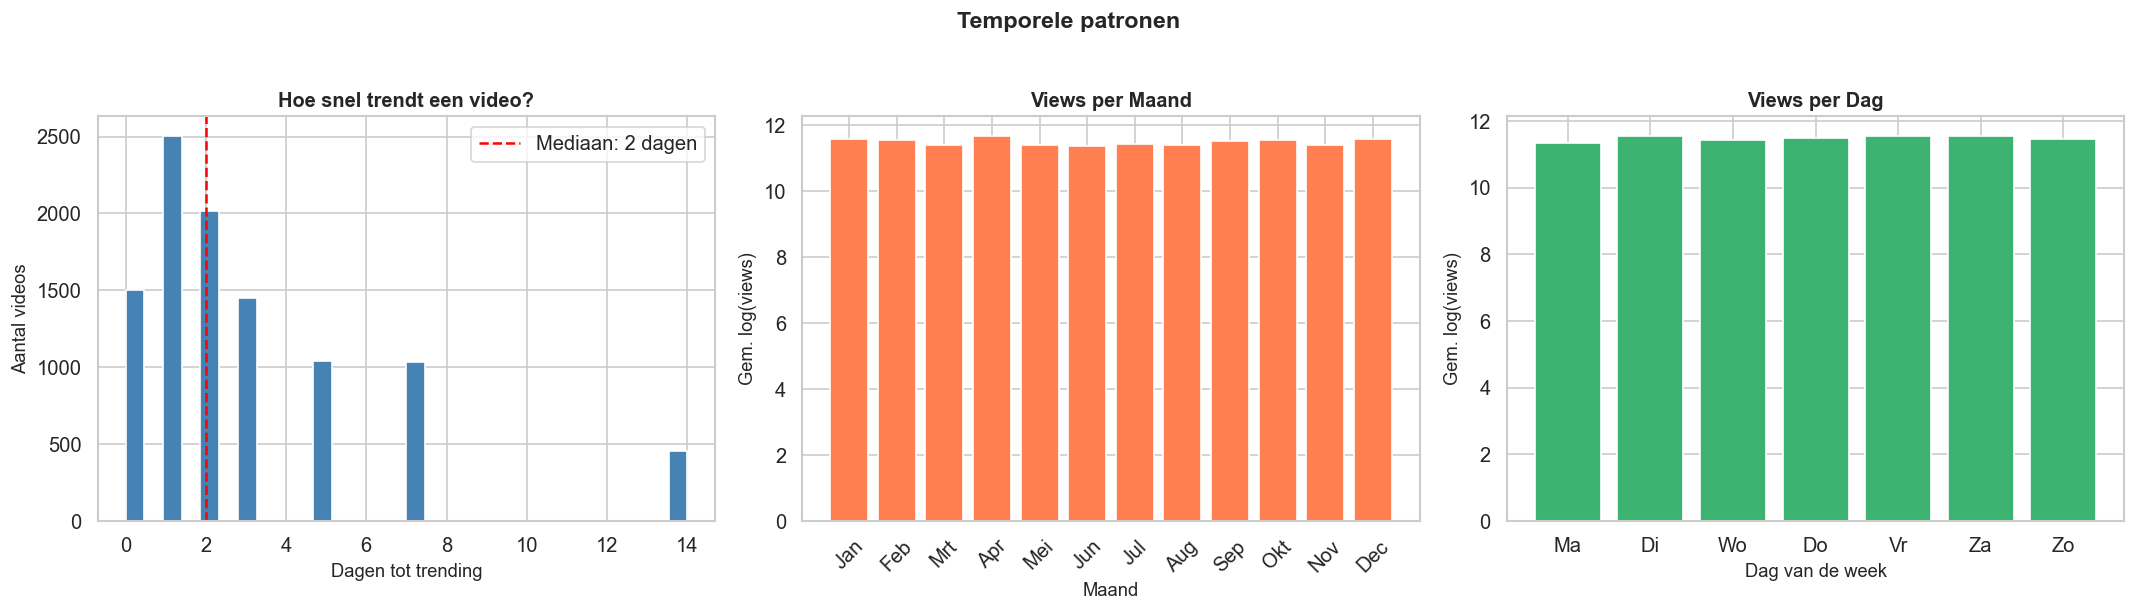

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['days_to_trend'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Dagen tot trending', fontsize=11)
axes[0].set_ylabel('Aantal videos', fontsize=11)
axes[0].set_title('Hoe snel trendt een video?', fontsize=12, fontweight='bold')
median_days = df['days_to_trend'].median()
axes[0].axvline(median_days, color='red', linestyle='--', label=f'Mediaan: {median_days:.0f} dagen')
axes[0].legend()

month_order = list(range(1, 13))
month_names = ['Jan','Feb','Mrt','Apr','Mei','Jun','Jul','Aug','Sep','Okt','Nov','Dec']
monthly = df.groupby('month')['log_views'].mean().reindex(month_order)
axes[1].bar(month_names, monthly.values, color='coral', edgecolor='white')
axes[1].set_xlabel('Maand', fontsize=11)
axes[1].set_ylabel('Gem. log(views)', fontsize=11)
axes[1].set_title('Views per Maand', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_names = ['Ma','Di','Wo','Do','Vr','Za','Zo']
daily = df.groupby('day_of_week')['log_views'].mean().reindex(day_order)
axes[2].bar(day_names, daily.values, color='mediumseagreen', edgecolor='white')
axes[2].set_xlabel('Dag van de week', fontsize=11)
axes[2].set_ylabel('Gem. log(views)', fontsize=11)
axes[2].set_title('Views per Dag', fontsize=12, fontweight='bold')

plt.suptitle('Temporele patronen', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/figures/06_temporele_analyse.png')
plt.show()

## 10. Geverifieerde kanalen & kanaalgrootte

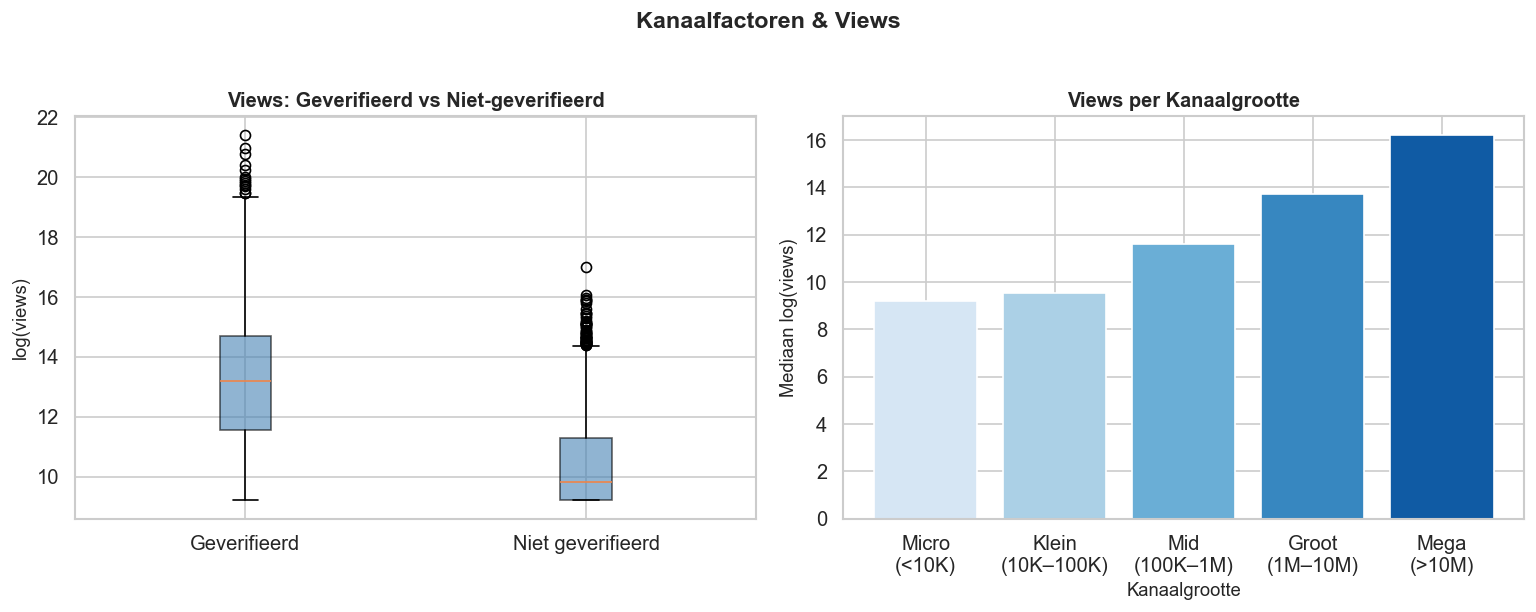

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

verified_data = [df[df['channel_verified'] == 1]['log_views'],
                 df[df['channel_verified'] == 0]['log_views']]
axes[0].boxplot(verified_data, labels=['Geverifieerd', 'Niet geverifieerd'],
                patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_ylabel('log(views)', fontsize=11)
axes[0].set_title('Views: Geverifieerd vs Niet-geverifieerd', fontsize=12, fontweight='bold')

df['channel_size_cat'] = pd.cut(
    df['subscriber_count'],
    bins=[0, 10_000, 100_000, 1_000_000, 10_000_000, float('inf')],
    labels=['Micro\n(<10K)', 'Klein\n(10K–100K)', 'Mid\n(100K–1M)', 'Groot\n(1M–10M)', 'Mega\n(>10M)']
)
size_views = df.groupby('channel_size_cat', observed=True)['log_views'].median()
axes[1].bar(size_views.index, size_views.values, color=sns.color_palette('Blues', 5))
axes[1].set_xlabel('Kanaalgrootte', fontsize=11)
axes[1].set_ylabel('Mediaan log(views)', fontsize=11)
axes[1].set_title('Views per Kanaalgrootte', fontsize=12, fontweight='bold')

plt.suptitle('Kanaalfactoren & Views', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/figures/07_kanaal_analyse.png')
plt.show()

## 11. Clickbait score & content-stijl

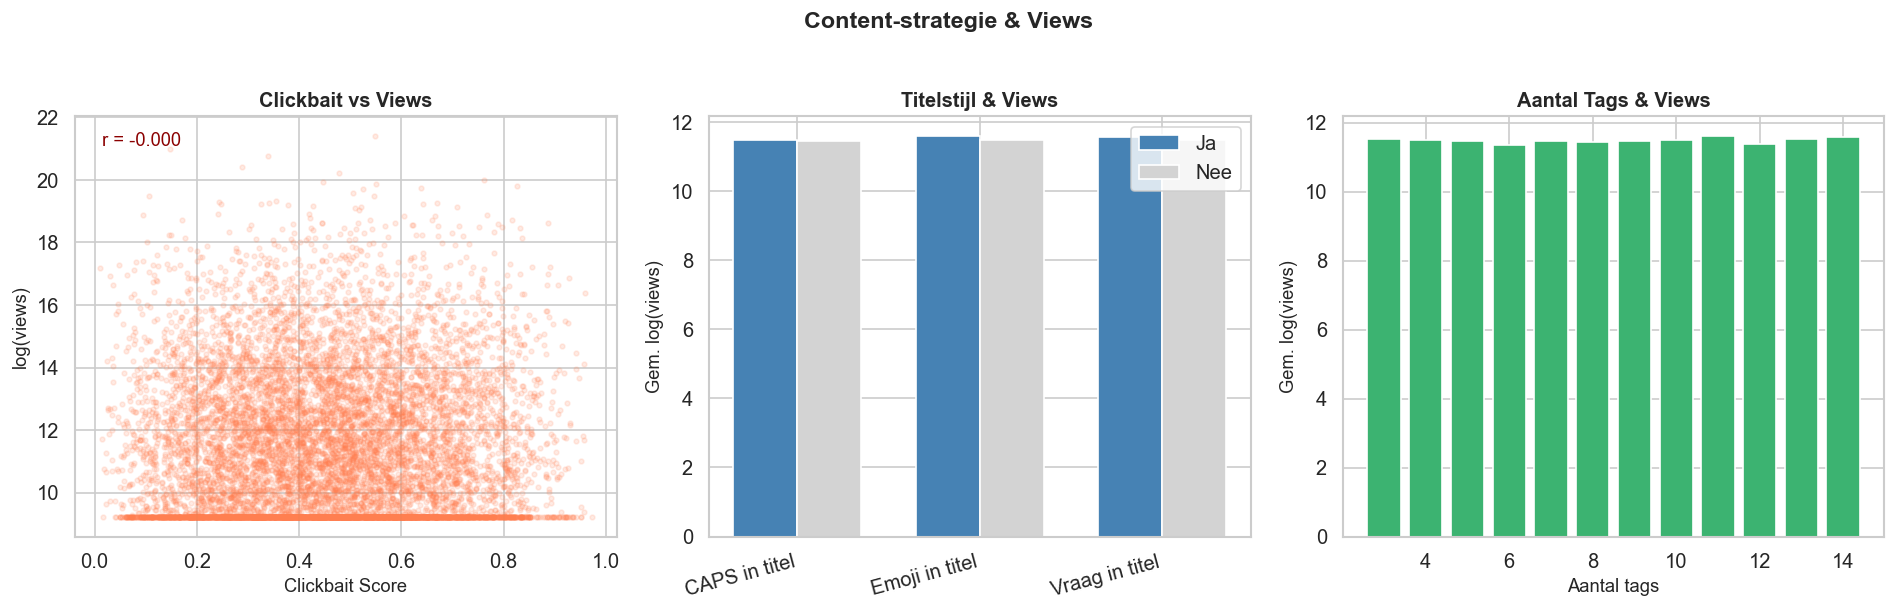

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df['clickbait_score'], df['log_views'], alpha=0.15, s=8, color='coral')
r_cb = df['clickbait_score'].corr(df['log_views'])
axes[0].set_xlabel('Clickbait Score', fontsize=11)
axes[0].set_ylabel('log(views)', fontsize=11)
axes[0].set_title('Clickbait vs Views', fontsize=12, fontweight='bold')
axes[0].text(0.05, 0.93, f'r = {r_cb:.3f}', transform=axes[0].transAxes, fontsize=11, color='darkred')

title_features = ['has_caps_title', 'has_emoji_title', 'has_question_title']
title_labels   = ['CAPS in titel', 'Emoji in titel', 'Vraag in titel']
means_yes = [df[df[f] == 1]['log_views'].mean() for f in title_features]
means_no  = [df[df[f] == 0]['log_views'].mean() for f in title_features]

x = np.arange(len(title_features))
w = 0.35
axes[1].bar(x - w/2, means_yes, w, label='Ja', color='steelblue')
axes[1].bar(x + w/2, means_no,  w, label='Nee', color='lightgray')
axes[1].set_xticks(x)
axes[1].set_xticklabels(title_labels, rotation=15, ha='right')
axes[1].set_ylabel('Gem. log(views)', fontsize=11)
axes[1].set_title('Titelstijl & Views', fontsize=12, fontweight='bold')
axes[1].legend()

tag_views = df.groupby('tag_count')['log_views'].mean()
axes[2].bar(tag_views.index, tag_views.values, color='mediumseagreen')
axes[2].set_xlabel('Aantal tags', fontsize=11)
axes[2].set_ylabel('Gem. log(views)', fontsize=11)
axes[2].set_title('Aantal Tags & Views', fontsize=12, fontweight='bold')

plt.suptitle('Content-strategie & Views', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/figures/08_content_strategie.png')
plt.show()

## 12. Geografische analyse

Verschilt het aantal views sterk tussen landen en talen?

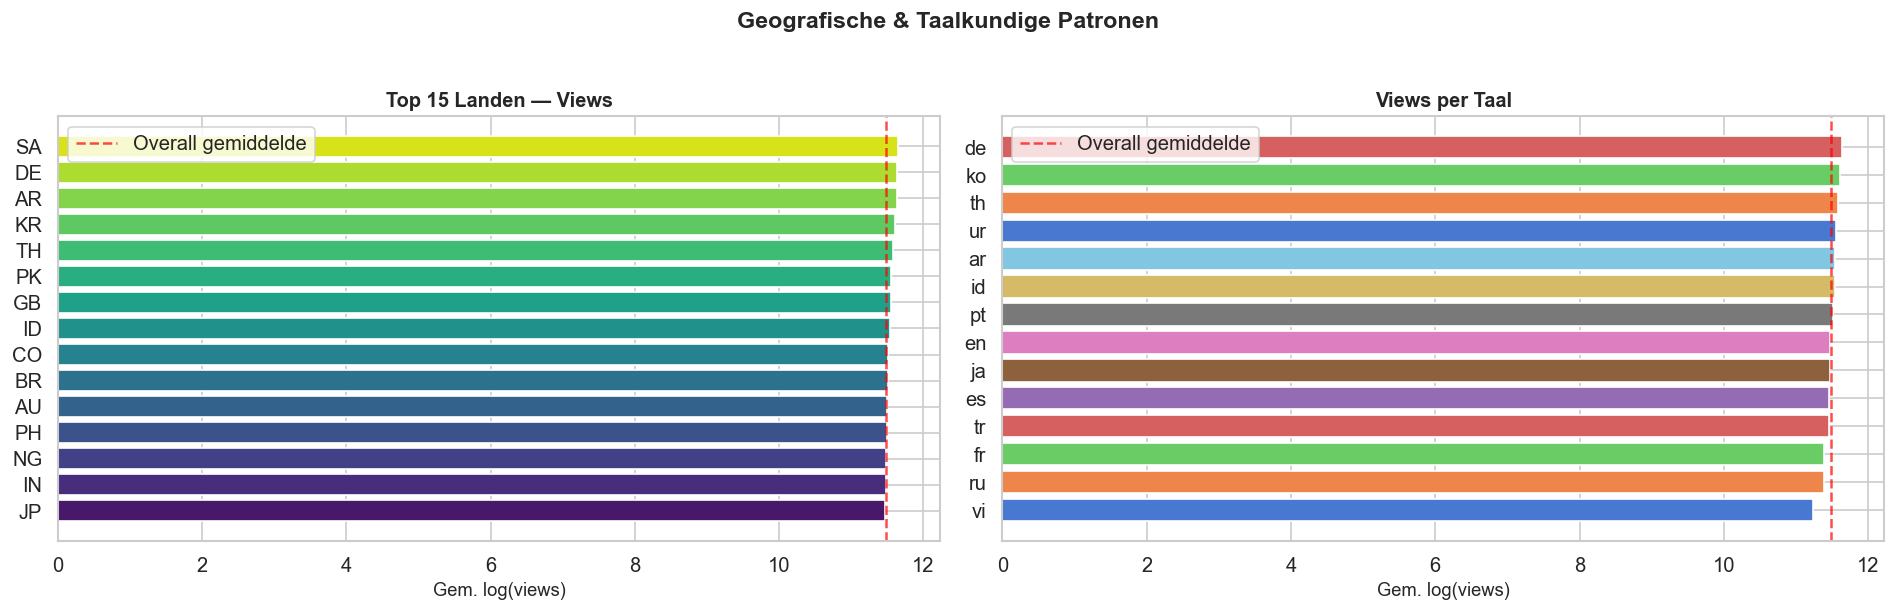

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

country_views = df.groupby('trending_country')['log_views'].agg(['mean', 'count'])
country_views = country_views[country_views['count'] >= 50].sort_values('mean', ascending=True).tail(15)
axes[0].barh(country_views.index, country_views['mean'],
             color=sns.color_palette('viridis', len(country_views)))
axes[0].axvline(df['log_views'].mean(), color='red', linestyle='--', alpha=0.7, label='Overall gemiddelde')
axes[0].set_xlabel('Gem. log(views)', fontsize=11)
axes[0].set_title('Top 15 Landen — Views', fontsize=12, fontweight='bold')
axes[0].legend()

lang_views = df.groupby('language')['log_views'].agg(['mean', 'count'])
lang_views = lang_views[lang_views['count'] >= 50].sort_values('mean', ascending=True)
axes[1].barh(lang_views.index, lang_views['mean'],
             color=sns.color_palette('muted', len(lang_views)))
axes[1].axvline(df['log_views'].mean(), color='red', linestyle='--', alpha=0.7, label='Overall gemiddelde')
axes[1].set_xlabel('Gem. log(views)', fontsize=11)
axes[1].set_title('Views per Taal', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Geografische & Taalkundige Patronen', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/figures/09_geografisch.png')
plt.show()

## 13. Target variabele in detail: log_views

Voor regressie kijken we naar de verdeling van `log_views`: is ze normaal verdeeld?

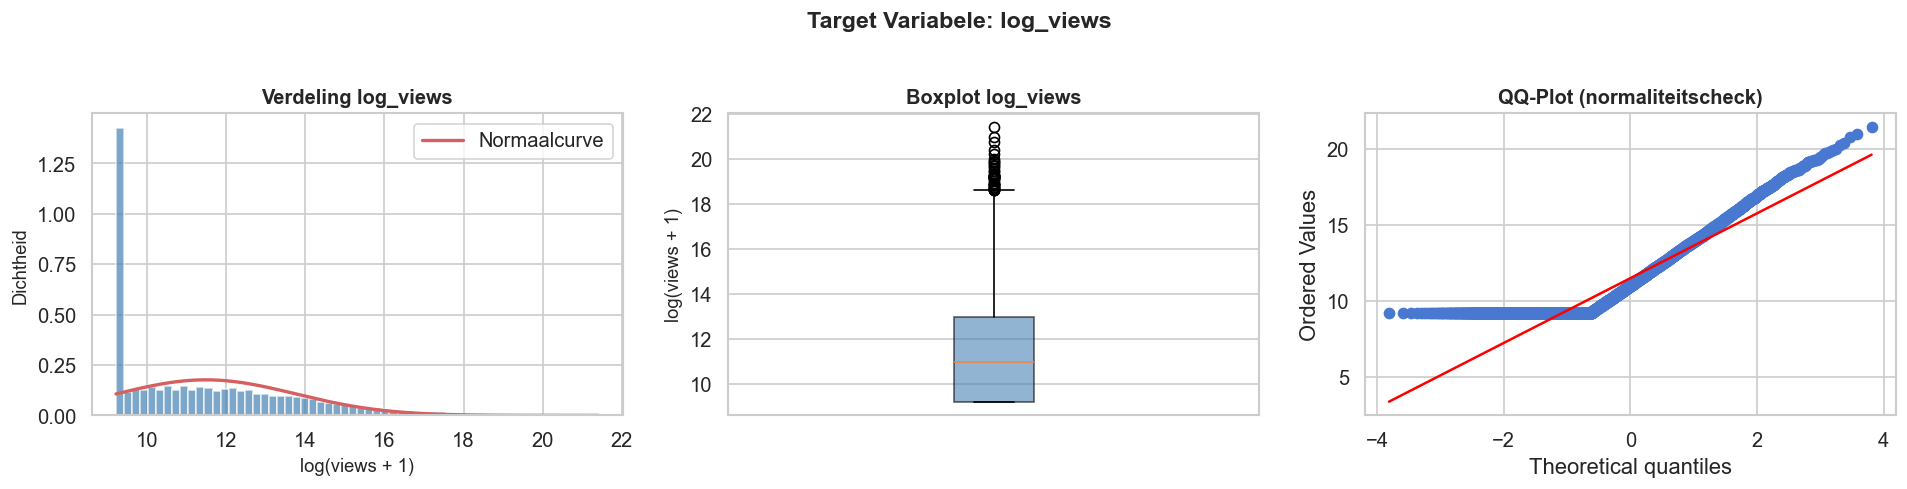

Scheefheid (skewness): 0.898  →  |skew| < 0.5 = quasi-normaal
Gemiddelde log_views: 11.49  →  exp(11.5) ≈ 97,250 views


In [17]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['log_views'], bins=60, density=True,
             color='steelblue', edgecolor='white', alpha=0.7)
mu, sigma = df['log_views'].mean(), df['log_views'].std()
x = np.linspace(df['log_views'].min(), df['log_views'].max(), 300)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normaalcurve')
axes[0].set_xlabel('log(views + 1)', fontsize=11)
axes[0].set_ylabel('Dichtheid', fontsize=11)
axes[0].set_title('Verdeling log_views', fontsize=12, fontweight='bold')
axes[0].legend()

axes[1].boxplot(df['log_views'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_xticks([])
axes[1].set_ylabel('log(views + 1)', fontsize=11)
axes[1].set_title('Boxplot log_views', fontsize=12, fontweight='bold')

stats.probplot(df['log_views'], dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot (normaliteitscheck)', fontsize=12, fontweight='bold')
axes[2].get_lines()[1].set_color('red')

plt.suptitle('Target Variabele: log_views', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/figures/10_target_variabele.png')
plt.show()

skewness = df['log_views'].skew()
print(f'Scheefheid (skewness): {skewness:.3f}  →  |skew| < 0.5 = quasi-normaal')
print(f'Gemiddelde log_views: {mu:.2f}  →  exp({mu:.1f}) ≈ {int(np.expm1(mu)):,} views')

## 14. Samenvatting EDA — Kernbevindingen

| # | Bevinding | Implicatie voor modellering |
|---|---|---|
| 1 | **`log_views` is de juiste target** — engagement_score had geen verband met pre-pub features | Log-transformatie van views als doelvariabele |
| 2 | **Views, likes en subscriber_count zijn sterk scheef** | Log-transformatie vereist in preprocessing |
| 3 | **`log_views` is quasi-normaal verdeeld** | Directe regressie mogelijk zonder verdere transformatie |
| 4 | **Abonneeaantal correleert het sterkst met views** | `log_subscriber_count` = belangrijkste feature |
| 5 | **Categorie heeft duidelijke invloed op views** | Categorische encoding nodig |
| 6 | **Geografische en taalkundige patronen zijn zichtbaar** | Land en taal toevoegen als features |
| 7 | **Clickbait score heeft beperkte lineaire correlatie** | Niet-lineaire modellen zullen dit beter vangen |
| 8 | **Geen missing values** | Geen imputatie nodig |

---

**Volgende stap:** `02_preprocessing_pipelines.ipynb` — data klaarmaken voor modellering.